# 📣 Marketing Attribution & A/B Test Analysis

**Dataset:** [Marketing Campaign Performance Dataset](https://www.kaggle.com/datasets/manishabhatt22/marketing-campaign-performance-dataset) — Kaggle  
**Records:** 200,000 marketing campaigns  
**Tools:** Python · pandas · scipy · matplotlib

---

## 🎯 Project Goal

Identify the best-performing marketing channel by Conversion Rate and ROI.  
Apply statistical testing (t-test, ANOVA) to determine whether observed differences are significant or random.

---

## 📋 Contents

1. Setup & Data Loading  
2. Data Overview  
3. EDA: Channel Performance  
4. Visualisation  
5. A/B Test: t-test (Facebook vs Instagram)  
6. A/B Test: ANOVA (all 6 channels)  
7. Business Conclusion

## 1. Setup & Data Loading

Import libraries and load the dataset.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

df = pd.read_csv('marketing_campaign_dataset.csv')

## 2. Data Overview

Check dataset dimensions and column types.

In [6]:
df.shape

(200000, 16)

In [7]:
df.dtypes

,0
Campaign_ID,int64
Company,object
Campaign_Type,object
Target_Audience,object
Duration,object
Channel_Used,object
Conversion_Rate,float64
Acquisition_Cost,object
ROI,float64
Location,object


In [8]:
df.head()

,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Date
0,1,Innovate Industries,Email,Men 18-24,30 days,Google Ads,0.04,"$16,174.00",6.29,Chicago,Spanish,506,1922,6,Health & Wellness,2021-01-01
1,2,NexGen Systems,Email,Women 35-44,60 days,Google Ads,0.12,"$11,566.00",5.61,New York,German,116,7523,7,Fashionistas,2021-01-02
2,3,Alpha Innovations,Influencer,Men 25-34,30 days,YouTube,0.07,"$10,200.00",7.18,Los Angeles,French,584,7698,1,Outdoor Adventurers,2021-01-03
3,4,DataTech Solutions,Display,All Ages,60 days,YouTube,0.11,"$12,724.00",5.55,Miami,Mandarin,217,1820,7,Health & Wellness,2021-01-04
4,5,NexGen Systems,Email,Men 25-34,15 days,YouTube,0.05,"$16,452.00",6.50,Los Angeles,Mandarin,379,4201,3,Health & Wellness,2021-01-05


## 3. EDA: Channel Performance

Clean `Acquisition_Cost` (stored as string with `$`) and compute average Conversion Rate, ROI, and CAC per channel.

In [9]:
df['Acquisition_Cost'] = (
    df['Acquisition_Cost'].str.replace('[$,]', '', regex=True).astype(float)
)

df.groupby('Channel_Used')[['Conversion_Rate', 'ROI', 'Acquisition_Cost']].mean().round(3).sort_values('Conversion_Rate', ascending=False)

,Conversion_Rate,ROI,Acquisition_Cost
Channel_Used,,,
Email,0.08,4.996,12526.388
Facebook,0.08,5.019,12510.901
Google Ads,0.08,5.003,12528.031
Instagram,0.08,4.989,12491.760
Website,0.08,5.014,12487.815
YouTube,0.08,4.994,12481.390


## 4. Visualisation

### 4.1 Average Conversion Rate by Channel

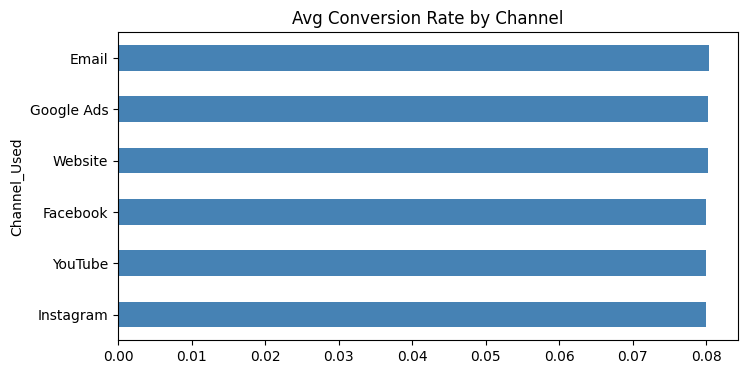

In [10]:
conversion_by_channel = df.groupby('Channel_Used')['Conversion_Rate'].mean().sort_values()

conversion_by_channel.plot(kind='barh', color='steelblue', figsize=(8, 4), title='Avg Conversion Rate by Channel')
plt.show()

### 4.2 Average ROI by Channel

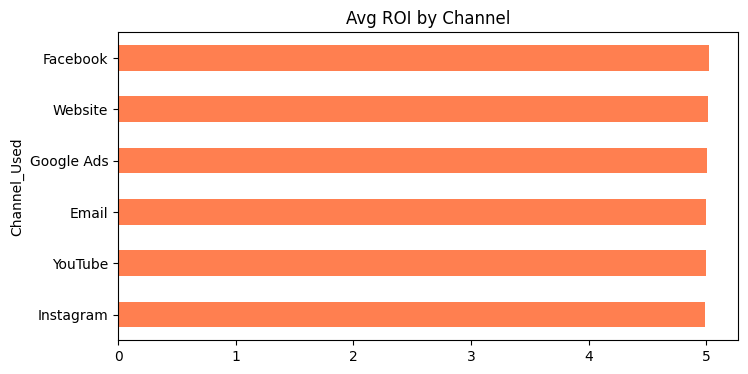

In [11]:
roi_by_channel = df.groupby('Channel_Used')['ROI'].mean().sort_values()

roi_by_channel.plot(kind='barh', color='coral', figsize=(8, 4), title='Avg ROI by Channel')
plt.show()

### 4.3 Conversion Rate Distribution (Boxplot)

Box shows the interquartile range (25%–75%). Green line = median. Whiskers = min/max without outliers.

In [12]:
facebook = df[df['Channel_Used'] == 'Facebook']['Conversion_Rate']
instagram = df[df['Channel_Used'] == 'Instagram']['Conversion_Rate']

t_stat, p_value = stats.ttest_ind(facebook, instagram)
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")

t-statistic: 0.3342
p-value: 0.7382


## 5. A/B Test: t-test (Facebook vs Instagram)

**Hypotheses:**
- H₀: No significant difference in Conversion Rate between Facebook and Instagram
- H₁: A significant difference exists

**Significance level:** α = 0.05 → if p-value < 0.05, we reject H₀

In [13]:
groups = [group['Conversion_Rate'].values for _, group in df.groupby('Channel_Used')]

f_stat, p_value_anova = stats.f_oneway(*groups)
print(f"F-statistic: {f_stat:.4f}")
print(f"p-value: {p_value_anova:.4f}")

F-statistic: 0.5793
p-value: 0.7159


## 6. A/B Test: ANOVA (all 6 channels)

t-test compares 2 groups. ANOVA answers: *is there a significant difference anywhere across all 6 channels?*

**Hypotheses:**
- H₀: All channels have equal mean Conversion Rate
- H₁: At least one channel differs significantly

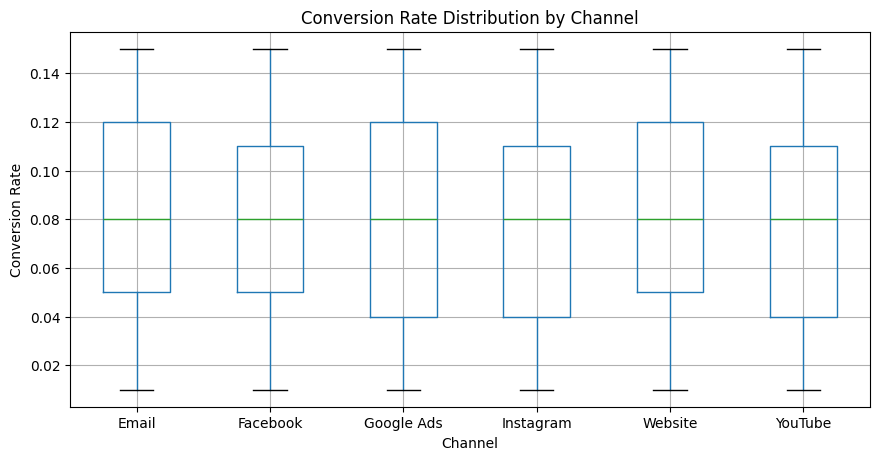

In [14]:
df.boxplot(column='Conversion_Rate', by='Channel_Used', figsize=(10, 5))
plt.title('Conversion Rate Distribution by Channel')
plt.suptitle('')
plt.xlabel('Channel')
plt.ylabel('Conversion Rate')
plt.show()

## 7. Business Conclusion

**Goal:** Identify the best-performing marketing channel by Conversion Rate and ROI.

**Method:** EDA → t-test (Facebook vs Instagram) → ANOVA (all 6 channels)

**Results:**
- All channels show identical Conversion Rate (0.08) and ROI (5.0)
- t-test p-value: **0.7382** → no significant difference between best and worst channel
- ANOVA p-value: **0.7159** → no significant difference across all 6 channels

**Recommendation:**  
There is no statistical evidence to reallocate budget between channels.  
Decisions should be based on CAC and audience targeting, not conversion rate alone.  
Dataset is synthetic — in real data, channels would show meaningful variation.